In [3]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Absorbance')

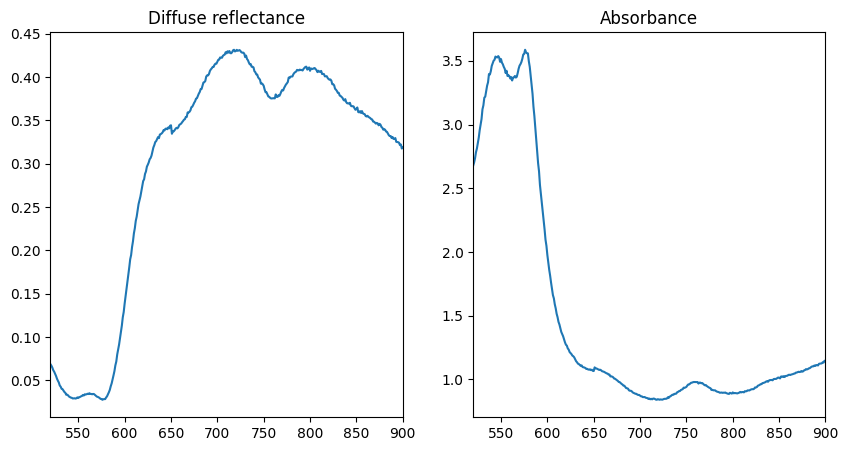

In [7]:
bands_range = [520,900]
band_centers = np.arange(bands_range[0], bands_range[1]+1)

R_spec = np.zeros(band_centers.shape[0])
R_diff = np.zeros(band_centers.shape[0])
for i in range(band_centers.shape[0]):
    output_file = os.path.join(f"{band_centers[i]}.mco")
    f = open(output_file, "r")
    for line in f:
        if "Specular reflectance" in line:
            R_spec[i] = float(line.split()[0])
        if "Diffuse reflectance" in line:
            R_diff[i] = float(line.split()[0])
    f.close()

fig, axs = plt.subplots(1, 2, figsize=(10,5), sharex=True)
# plt.plot(band_centers, R_spec, label="R_spec")
axs[0].plot(band_centers, R_diff, label="R_diffuse")
axs[0].set_xlim(bands_range)
axs[0].set_title("Diffuse reflectance")

absorbance = -np.log(R_diff)
axs[1].plot(band_centers, absorbance, label="absorbance")
# axs[1].set_xlim(bands_range)
axs[1].set_title("Absorbance")